<!DOCTYPE html>
<html lang="en" dir="ltr">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Data Cleaning Steps Summary</title>
    <!-- Load Tailwind CSS -->
    <script src="https://cdn.tailwindcss.com"></script>
    <style>
        /* Custom Font for readability */
        @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap');
        body {
            font-family: 'Inter', sans-serif;
            background-color: #f7f9fb;
        }
        .card {
            box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.1), 0 5px 15px -5px rgba(0, 0, 0, 0.04);
        }
        .step-icon {
            min-width: 2.5rem;
            min-height: 2.5rem;
            display: flex;
            align-items: center;
            justify-content: center;
        }
    </style>
</head>



<!DOCTYPE html>
<html lang="en" dir="ltr">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Data Cleaning Steps Summary</title>
    <!-- Load Tailwind CSS -->
    <script src="https://cdn.tailwindcss.com"></script>
    <style>
        /* Custom Font for readability */
        @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap');
        body {
            font-family: 'Inter', sans-serif;
            /* Dark background for VS Code Dark Theme */
            background-color: #ffffffff; /* VS Code background color */
            color: #4637b9ff; /* Default text color for dark theme */
        }
        .card {
            /* Adjusted box shadow for dark mode */
            box-shadow: 0 4px 10px rgba(0, 0, 0, 0.4);
            /* Darker card background */
            background-color: #252526; /* VS Code sidebar/panel color */
        }
        .header-bg {
            /* Slightly different background for header contrast */
            background-color: #333333;
        }
    </style>
</head>
<body class="p-4 sm:p-8">

<div class="max-w-4xl mx-auto">
    <header class="text-center mb-10 p-6 rounded-xl card header-bg">
            <h1 class="text-3xl sm:text-4xl font-extrabold text-blue-400 mb-2">Summary of Data Cleaning and Transformation Work</h1>
            <p class="text-lg text-gray-400">A brief report detailing the steps taken to prepare the job data for analysis.</p>
    </header>
    <section class="space-y-8">
            <!-- Section 1: Salary Transformation -->
            <div class="p-6 rounded-xl card border-t-4 border-blue-500">
                <h2 class="text-2xl font-bold text-blue-400 mb-4">1. Salary Transformation and Structuring</h2>
                <ul class="list-disc list-outside space-y-3 text-gray-300 ml-5">
                    <li>**Split Salary Range:** The text column `Salary_range` (e.g., '5000-8000') was split into two new columns: `Min_Salary` and `Max_Salary`.</li>
                    <li>**Convert to Numeric:** Both columns (`Min_Salary` and `Max_Salary`) were converted to the **`float64`** data type using the `pd.to_numeric(..., errors='coerce')` function.</li>
                    <li>**Handle Undisclosed Salaries:** Any unconvertible values or zeros (`0.0`) were replaced with the standard missing value marker **`NaN`** to ensure accuracy in statistical calculations.</li>
                </ul>
            </div>
            <!-- Section 2: Categorical Standardization -->
            <div class="p-6 rounded-xl card border-t-4 border-green-500">
                <h2 class="text-2xl font-bold text-green-400 mb-4">2. Categorical Standardization and Cleaning</h2>
                <ul class="list-disc list-outside space-y-3 text-gray-300 ml-5">
                    <li>**Currency Standardization:** Typographical errors and inconsistencies in the `currency_name` column were corrected to ensure data uniformity (e.g., unifying 'Egyption Pound' to **'Egyptian Pound'**).</li>
                    <li>**Period Standardization:** The formatting in the `salary_period` column (e.g., 'Per Month') was unified to simplify filtering and grouping operations.</li>
                </ul>
            </div>
            <!-- Section 3: Structural Readiness -->
            <div class="p-6 rounded-xl card border-t-4 border-purple-500">
                <h2 class="text-2xl font-bold text-purple-400 mb-4">3. Structural Readiness for Analysis</h2>
                <ul class="list-disc list-outside space-y-3 text-gray-300 ml-5">
                    <li>**Error Handling:** Parentheses were correctly used in complex filtering operations to prevent common Pandas precedence errors (e.g., `TypeError`).</li>
                    <li>**Outlier Filtering:** Inverse logical filtering techniques (`df[~condition]`) were applied to handle anomalous rows (such as unrealistic salary values).</li>
                    <li>**Next Steps:** Date columns (like `post_date`) were prepared for conversion to the `datetime` type, and experience columns (like `experience_years`) were prepared for further segmentation into numerical values.</li>
                </ul>
            </div>
        </section>
        <footer class="mt-10 text-center text-gray-500 text-sm p-4 rounded-xl card header-bg">
            <p>This report summarizes the essential data cleaning operations performed on the job postings dataset.</p>
        </footer>
    </div>

</body>
</html>


In [390]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_excel(r"E:\.Eng_Ahmed\Data Engineer\Wuzzuf_Jobs_2020-2021 (1).xlsx",index_col=0)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54856 entries, xg-ydxj to 03-v2du
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         54856 non-null  object
 1   city              54856 non-null  object
 2   job_category1     54818 non-null  object
 3   job_category2     35435 non-null  object
 4   job_category3     11935 non-null  object
 5   industry1         44046 non-null  object
 6   industry2         44046 non-null  object
 7   industry3         44046 non-null  object
 8   Salary_range      54856 non-null  object
 9   num_vacancies     54856 non-null  int64 
 10  career_level      54856 non-null  object
 11  experience_years  54163 non-null  object
 12  post_date         54856 non-null  object
 13  views             54856 non-null  int64 
 14  salary_period     54856 non-null  object
 15  currency_name     54856 non-null  object
dtypes: int64(2), object(14)
memory usage: 7.1+ MB


In [5]:
df.drop_duplicates(inplace=True)
# to remove all duplicate rows
df.dropna(how='all',inplace=True)
# to remove all empty rows
df.info()
# there were 28 duplicate rows and no empty rows

<class 'pandas.core.frame.DataFrame'>
Index: 54828 entries, xg-ydxj to 03-v2du
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         54828 non-null  object
 1   city              54828 non-null  object
 2   job_category1     54790 non-null  object
 3   job_category2     35434 non-null  object
 4   job_category3     11935 non-null  object
 5   industry1         44020 non-null  object
 6   industry2         44020 non-null  object
 7   industry3         44020 non-null  object
 8   Salary_range      54828 non-null  object
 9   num_vacancies     54828 non-null  int64 
 10  career_level      54828 non-null  object
 11  experience_years  54135 non-null  object
 12  post_date         54828 non-null  object
 13  views             54828 non-null  int64 
 14  salary_period     54828 non-null  object
 15  currency_name     54828 non-null  object
dtypes: int64(2), object(14)
memory usage: 7.1+ MB


In [6]:
df['city']=df['city'].str.title()
# to make the first letter of each word in the city column capital    

In [7]:
mapping = {
    'Giza': ['Giz'], 'Alexandria': ['Lexndri'], 'Cairo': [], 'Ismailia': ['Ismili'],'Gharbia': ['Ghrbi'], 'Sharqia': ['Shrqi'], 'Dallas': [], 'Chennai': [],'Monufya': ['Monufy'], 'Beni Suef': [], 'Suez': [], 'Port Said': ['Port Sid'],
    'Damietta': ['Dmiett'], 'Dakahlia': ['Dkhli'], 'Riyadh': ['Riydh'],
    'Abu Dhabi': [], 'Sharjah': [], 'Beheira': ['Beheir'], 'Porto Alegre': ['Porto Legre'],
    'Red Sea': ['Red Se'], 'Jeddah': ['Jeddh'], 'Coronel Fabriciano': [],
    'Toronto': [], 'Luxor': [], 'Assiut': ['Ssiut'], 'Amman': [], 'Matruh': [],
    'Fortaleza': [], 'Dubai': ['Dubi'], 'Hong Kong': [], 'Kafr Alsheikh': [],
    'Bucharest': [], 'Brasilia': [], 'Qalubia': ['Qlubi'], 'Benghazi': [],
    'Doha': ['Doh'], 'Aswan': [], 'Sohag': [], 'Minya': ['Miny'], 'Muscat': [],
    'Fayoum': ['Fyoum'], 'Cochin': [], 'Mangalore': [], 'Qena': ['Qen'],
    'Manila': [], 'South Sinai': ['South Sini'], 'Chandigarh': [], 'Lima': [],
    'North Sinai': [], 'Ahmedabad': [], 'Chengdu': [], 'Salvador': [],
    'Vienna': [], 'Hyderabad': [], 'Qassim': [], 'Makkah': [], 'Dammam': ['Dmmm'],
    'Abha': [], 'Khobar': ['Khobr'], 'Lobito': [], 'Kuwait City': [],
    'Bengaluru': [], 'Colombo': [], 'Kolkata': [], 'Tripoli': [],
    'Khamis Mushait': [], 'New Valley': ['New Vlley'], 'Mississauga': [],
    'Tunis': [], 'Mumbai': [], 'London': ['City Of London'], 'Ar Rass': [],
    'Munich': [], 'Ajman': [], 'Palembang': [], 'Istanbul': [], 'Riga': [],
    'Madinat `Isa': [], 'Rabat': [], 'Krakow': [], 'Niamey': [], 'Baghdad': [],
    'Mohali': [], 'Jodhpur': [], 'Adelaide': [], 'New York City': [],
    'Lahore': [], 'Ghaziabad': [], 'Lviv': [], 'Berlin': [],
    'Belo Horizonte': [], 'Wyoming': [], 'Qunfudhah': [], 'Hisar': [],
    'Halifax': [], 'Bukoba': [], 'Hamburg': [], 'Upland': [],
    'Islamabad': [], 'Nice': [], 'Kuala Lumpur': [], 'Jalandhar': [],
    'Salmiya': [], 'Dandong': [], 'Sirte': [], 'Manama': [],
    'Ad Dasmah': [], 'Gabes': [], 'Nairobi': [], 'Malang': [],
    'Paris': [], 'Kiev': [], 'Sliven': [], 'Moscow': [],'Farwaniya': [], 'Al Kharj': [], 'Latakia': [], 'Armenia': [],
    'Chicago': [], 'Delhi': [], 'Vancouver': [], 'Vadodara': [],
    'Navi Mumbai': [], 'Ankara': [], 'Zagreb': [], 'Yanbu': [],
    'Hawally': [], 'Atbara': [], 'Gurgaon': [], 'Beirut': [],
    'Boston': [], 'Algiers': [], 'Nablus': [], 'Dhaka': [],
    'Bexley': [], 'Sofia': [], 'Asir': [], 'Vitoria': [],
    'Jazan': [], 'Brasov': [], 'Sydney': [], 'Denver': [],
    'Athens': [], 'Monastir': [], 'Male': [], 'Hebron': [],
    'Sousse': [], 'El Jadida': [], 'Kampala': [], 'St. Petersburg': [],
    'Sacramento': [], 'Budapest': [], 'Novo Hmburgo': [], 'Butare': [],
    'Belgrade': [], 'Tallinn': [], 'Sabah As Salim': [], 'Milan': [],
    'Al Ahsa': [], 'Karachi': [], 'Stamford': [], 'Los Angeles': [],
    'Qal`At Bishah': [], 'Sur': [], 'Kedungwuni': [], 'Cairns': [],
    'Zahle': [], 'Shenzhen': [], 'Hamilton': [], 'Al Buraymi': [],
    'Amsterdam': [], 'Muhayil Asir': [], 'Al Muharraq': [], 'Al Ain': [],
    "Ar Rifa'": [], 'Panvel': [], 'Stockholm': [], 'Madinat Hamad': [],'Madina': [], 'Barcelona': [], 'Buraydah': [], 'Al Jawf': [],'Kumanovo': [], 'Montevideo': [], 'Jaipur': [], 'Manchester': [],'Lille': [], 'Bandung': [], 'Aksaray': [], 'Ciranjang-Hilir': [],'As Sulaymaniyah': [], 'Beijing': [], 'Salalah': [], 'Al Mahbulah': [],'Livonia': [], 'Fresno': [], 'Toledo': [], 'Batala': [],'Buenos Aires': [], 'Abohar': [], 'Portsmouth': [], 'Baltimore': [],'San Salvador': [], 'Montreal': [], 'Nashik': [], 'Ludhiana': [], 'Florianopolis': [], 'Laval': [], 'Al Ahmadi': [], 'Sao Carlos': [],'Vaughan': [], 'Maringa': [], 'Erbil': [], 'Pickering': [],'Kedungwaru': []
}

replacement_dict = {}
for correct_name, misspellings in mapping.items():
    for misspelling in misspellings:
        replacement_dict[misspelling] = correct_name

df['city'] = df['city'].replace(replacement_dict)
# to correct the misspelled city names

In [8]:
df['job_title'][df['job_category1'].isnull()]

Job ID
i6-bfjo            Digital Marketing Specialist - Alexandria
57-3zdx                                        HVAC Engineer
da-573q                         Electronics Engineer - Cairo
p2-x109            Customer Service Specialist (Collections)
u5-ip2l                              Human Resources Manager
vl-7rsp                                            Secretary
jv-8xx9                    Quality Control Senior Specialist
jn-8nqj                                          Art Teacher
46-yqrf                                       Hse Specialist
5k-5ia7                ESL Instructor Online ( Females Only)
jc-ouvj                             Legal Advisor - Hurghada
jk-um37                Integration & Architecture Consultant
o1-xnto                                E-Learning Consultant
yf-jg04                                 Sales Representative
kf-lbdl               Firefighting Technical Office Engineer
ao-et08                    Electrical Engineer (BIM - Revit)
0z-azc4          

In [9]:
job_category_mapping = {
    # ------------------ Marketing & Sales ------------------
    'Digital Marketing Specialist - Alexandria': 'Marketing & Sales',
    'Sales Representative': 'Marketing & Sales',
    'Sales Manager': 'Marketing & Sales',
    'Indirect Sales Representative': 'Marketing & Sales',
    'Real Estate Sales Representative': 'Marketing & Sales',
    'Sales Representative-Cairo': 'Marketing & Sales',
    'Sales Executive': 'Marketing & Sales',
    'Sales Executive - Mansoura': 'Marketing & Sales',
    'Brand Manager': 'Marketing & Sales',


    'HVAC Engineer': 'Engineering & Technical',
    'Electronics Engineer - Cairo': 'Engineering & Technical',
    'Firefighting Technical Office Engineer': 'Engineering & Technical',
    'Electrical Engineer (BIM - Revit)': 'Engineering & Technical',
    'Site Electrical Engineer (Light Current Systems)': 'Engineering & Technical',
    'Technical Office Engineer': 'Engineering & Technical',
    'Agricultural Engineering Manager - Sharqia': 'Engineering & Technical',

    # ------------------ HR & Administration ------------------
    'Human Resources Manager': 'HR & Administration',
    'Secretary': 'HR & Administration',
    'Personal Assistant TO CEO': 'HR & Administration',
    'Registrar Manager': 'HR & Administration',
    'HR Manager': 'HR & Administration',
    'HR Generalist': 'HR & Administration',
    'Legal Advisor - Hurghada': 'Legal & Administration', # Separated Legal
    
    # ------------------ Logistics & Supply Chain ------------------
    'Export Manager': 'Logistics & Supply Chain',
    'Store Keeper': 'Logistics & Supply Chain',
    'Drivers - Riyadh': 'Logistics & Supply Chain',
    'Export Station Manager': 'Logistics & Supply Chain',

    # ------------------ Education & Training ------------------
    'Art Teacher': 'Education & Training',
    'ESL Instructor Online ( Females Only)': 'Education & Training',
    'E-Learning Consultant': 'Education & Training',
    'ESL Instructor Online - Females': 'Education & Training',

    # ------------------ IT & Consulting ------------------
    'Integration & Architecture Consultant': 'IT & Consulting',
    'Content Moderation Queue - English Speakers': 'IT & Consulting',

    # ------------------ Quality & Safety ------------------
    'Quality Control Senior Specialist': 'Quality & Safety',
    'Hse Specialist': 'Quality & Safety',

    # ------------------ Customer Service ------------------
    'Customer Service Specialist (Collections)': 'Customer Service'
}
df['job_category1'] = df['job_category1'].fillna(df['job_title'].map(job_category_mapping))
# to fill the missing values in job_category1 based on job_title


In [10]:
df.loc[df['job_category1'].isnull(), 'job_title'] = 'Real Estate Sales Representative'
# to fill the remaining missing values in job_category1 with a common job title

In [11]:
df['job_category2'].fillna('', inplace=True)
df['job_category3'].fillna('', inplace=True)
# to fill the missing values in job_category2 and job_category3 with empty strings

C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\496748099.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['job_category2'].fillna('', inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\496748099.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [12]:
df['industry1'].fillna('', inplace=True)
df['industry2'].fillna('', inplace=True)
df['industry3'].fillna('', inplace=True)
# to fill the missing values in industry1, industry2, and industry3 with empty strings

C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\2264725574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['industry1'].fillna('', inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\2264725574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [ ]:
(df['job_category3']=='').sum()
df['job_category3'].unique()
# to check how many empty values are in job_category3 and see the unique values in job_category3


array(['', 'Engineering - Other', 'Education/Teaching', 'Pharmaceutical',
       'Quality', 'Engineering - Telecom/Technology',
       'Engineering - Oil & Gas/Energy', 'Media/Journalism/Publishing',
       'Engineering - Mechanical/Electrical', 'Sales/Retail',
       'Project/Program Management', 'Training/Instructor',
       'C-Level Executive/GM/Director', 'Analyst/Research',
       'Marketing/PR/Advertising', 'Purchasing/Procurement',
       'Medical/Healthcare', 'IT/Software Development', 'Tourism/Travel',
       'Operations/Management',
       'Engineering - Construction/Civil/Architecture', 'Fashion',
       'Manufacturing/Production', 'Strategy/Consulting',
       'Customer Service/Support', 'Hospitality/Hotels/Food Services',
       'Sports and Leisure', 'Human Resources', 'Logistics/Supply Chain',
       'Other', 'Writing/Editorial', 'Banking',
       'Installation/Maintenance/Repair', 'Legal', 'Creative/Design/Art',
       'Business Development'], dtype=object)

In [14]:
(df['job_category2']=='').sum()
# to check how many empty values are in job_category2
df['job_category2'].unique()
# to see the unique values in job_category2

array(['', 'Fashion', 'Media/Journalism/Publishing', 'Sales/Retail',
       'Engineering - Telecom/Technology', 'Pharmaceutical',
       'Customer Service/Support', 'Manufacturing/Production',
       'Project/Program Management', 'IT/Software Development',
       'Engineering - Mechanical/Electrical', 'Engineering - Other',
       'Quality', 'Operations/Management', 'Tourism/Travel',
       'Human Resources', 'Training/Instructor',
       'Marketing/PR/Advertising', 'Purchasing/Procurement',
       'Business Development', 'Creative/Design/Art',
       'Hospitality/Hotels/Food Services', 'Administration',
       'Writing/Editorial', 'Medical/Healthcare', 'Legal',
       'Analyst/Research', 'Education/Teaching',
       'Installation/Maintenance/Repair', 'Banking',
       'Logistics/Supply Chain', 'Engineering - Oil & Gas/Energy',
       'C-Level Executive/GM/Director', 'Strategy/Consulting', 'Other',
       'R&D/Science', 'Engineering - Construction/Civil/Architecture',
       'Sports an

In [15]:
df['job_category2']=df['job_category2']+' '+df['job_category3']
# to merge job_category2 and job_category3 into job_category2

In [16]:
df.drop(columns=['job_category3'], inplace=True)
# to drop the job_category3 column as its information is now merged into job_category2

In [17]:
df['industry1'].replace('Information Technology & Services', 'IT & Software', inplace=True)
# to standardize the industry1 values
df['industry1'].replace('Select', '', inplace=True)
df['industry2'].replace('Select', '', inplace=True)
df['industry3'].replace('Select', '', inplace=True)
# to replace 'Select' with empty strings in industry columns


C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\2482746177.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['industry1'].replace('Information Technology & Services', 'IT & Software', inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\2482746177.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are settin

In [ ]:
(df['industry1']=='').sum()
# to check how many empty values are in industry1

np.int64(26789)

In [ ]:
df['industry1'].nunique()
# to check how many unique values are in industry1

103

In [20]:
df['industry2'].nunique()

90

In [21]:
df['industry2']=df['industry2']+' '+df['industry3']
# to merge industry2 and industry3 into industry2
df.drop(columns=['industry3'], inplace=True)
# to drop the industry3 column as its information is now merged into industry2

In [ ]:
df['currency_name'].value_counts()
df['currency_name'].replace('Estonian Kroon', 'Euro', inplace=True)
#توحيد لعملة "اليورو" لأن الكرون لم يعد متداولاً في إستونيا بعد عام 2011.


C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\3366942744.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['currency_name'].replace('Estonian Kroon', 'Euro', inplace=True)


In [23]:
df[df['Salary_range']=='0-0']
# to check the rows with '0-0' salary range
(df['Salary_range']=='0-0').sum()
# to count how many rows have '0-0' salary range

np.int64(616)

In [24]:
df[['Min_Salary','Max_Salary']]=df['Salary_range'].str.split('-',expand=True)
# to split the Salary_range column into Min_Salary and Max_Salary columns           


In [25]:
df.head()

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name,Min_Salary,Max_Salary
Job ID,,,,,,,,,,,,,,,,
xg-ydxj,HR Generalist,Giza,Human Resources,,Manufacturing,Packaging and Containers,5000-8000,1,Experienced (Non-Manager),5+,8/19/2020 15:13,1121,Per Month,Egyptian Pound,5000,8000
jl-u1bp,Fashion Project Engineer,Alexandria,Project/Program Management,Fashion Engineering - Other,,,4500-5000,1,Entry Level,0-3,9/27/2021 14:16,924,Per Month,Egyptian Pound,4500,5000
hy-tfoi,Content Creator,Cairo,Writing/Editorial,Media/Journalism/Publishing Education/Teaching,Publishing and Printing,,5000-8000,1,Experienced (Non-Manager),2025-03-04 00:00:00,2/22/2021 10:16,797,Per Month,Egyptian Pound,5000,8000
lb-94x2,Medical Sales Representative,Cairo,Medical/Healthcare,Sales/Retail Pharmaceutical,,,4000-10000,20,Experienced (Non-Manager),2+,2021-08-08 18:23:00,363,Per Month,Egyptian Pound,4000,10000
kl-4rzo,SAP FICO Functional Consultant,Cairo,IT/Software Development,Engineering - Telecom/Technology,Logistics and Supply Chain,Transportation,15000-20000,1,Experienced (Non-Manager),2025-03-05 00:00:00,2021-04-10 12:32:00,191,Per Month,Egyptian Pound,15000,20000


In [ ]:
df=df[['job_title','city','job_category1','job_category2','industry1','industry2','Salary_range','Min_Salary','Max_Salary','num_vacancies','career_level','experience_years','post_date','views','salary_period','currency_name']]
# to rearrange the columns

In [ ]:
df.columns=df.columns.str.strip()
# to remove any leading or trailing whitespaces from the column names

In [ ]:
df['Min_Salary'] = df['Min_Salary'].replace('0', np.nan)
df['Max_Salary'] = df['Max_Salary'].replace('0', np.nan)
df['Salary_range'].replace('0-0','Not Disclosed',inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\593881989.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary_range'].replace('0-0','Not Disclosed',inplace=True)


In [ ]:
df['Min_Salary'].replace('Aug',np.nan,inplace=True)
df['Min_Salary'].replace('Jan',np.nan,inplace=True)
df['Salary_range'].replace('Aug-00','Not Disclosed',inplace=True)
df['Salary_range'].replace('jan-00','Not Disclosed',inplace=True)

# to replace '0' with 'Not Disclosed' in Salary_range column and to replace 'Aug' and 'Jan' with 'Not Disclosed' in Min_Salary column

C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\1329775835.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Min_Salary'].replace('Aug',np.nan,inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\1329775835.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [30]:
df['Min_Salary'] = df['Min_Salary'].astype('Int64')
df['Max_Salary'] = df['Max_Salary'].astype('Int64')


In [ ]:
              data_check=pd.to_datetime(df['Salary_range'],errors='coerce')
              # to check the data type of Salary_range column
              data_check
              anomalous_indices = data_check.notna()
# to check the anomalous data in Salary_range column
anomalous_indices

C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\1943806664.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_check=pd.to_datetime(df['Salary_range'],errors='coerce')


Job ID
xg-ydxj    False
jl-u1bp    False
hy-tfoi    False
lb-94x2    False
kl-4rzo    False
           ...  
ya-qeei    False
p2-pkl1    False
iq-9dsx    False
ey-qbkp    False
03-v2du    False
Name: Salary_range, Length: 54828, dtype: bool

In [32]:
df.loc[anomalous_indices, 'Salary_range']='Not Disclosed'
# to replace the anomalous data in Salary_range column

In [ ]:
# pd.reset_option('display.max_columns', None)
df['Min_Salary'].value_counts()

Min_Salary
5000     6793
4000     5997
3000     5148
8000     4958
10000    4590
         ... 
1224        1
203         1
4312        1
11384       1
24900       1
Name: count, Length: 354, dtype: Int64

In [39]:
df['career_level'].value_counts()

career_level
Experienced (Non-Manager)           28403
Entry Level                         16486
Manager                              9133
Senior Management (e.g. VP, CEO)      412
Student                               394
Name: count, dtype: int64

In [59]:
# pd.set_option('display.max_columns', None)
df[(df['career_level']=='Student') & (df['Min_Salary']>1000)]

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,Min_Salary,Max_Salary,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name
Job ID,,,,,,,,,,,,,,,,
r0-bzt8,UI/UX Developer,Giza,Creative/Design/Art,IT/Software Development Engineering - Telecom/...,Marketing and Advertising,,3000-4000,3000,4000,1,Student,0-1,2020-02-06 14:09:00,1933,Per Month,Egyptian Pound
tf-15yg,Medical Graduate,Cairo,Medical/Healthcare,Education/Teaching,Education,,2500-5000,2500,5000,1,Student,1+,2020-10-04 20:28:00,1742,Per Month,Egyptian Pound
mz-59pe,C++ Software Engineer ( Internship),Giza,IT/Software Development,Engineering - Telecom/Technology,Computer Software,,6000-8000,6000,8000,5,Student,NaN,11/15/2021 14:17,2294,Per Month,Egyptian Pound
bu-niub,Food Review Writer,Cairo,Writing/Editorial,Hospitality/Hotels/Food Services,Business Services - Other,,2000-4000,2000,4000,2,Student,NaN,12/15/2020 8:11,4656,Per Month,Egyptian Pound
3s-ysl2,English Teacher at CNA Fortaleza-GT,Fortaleza,Education/Teaching,,Non-Profit Organizations,,1500-1540,1500,1540,1,Student,1+,2020-06-02 02:24:00,51,Per Month,Brazilian Real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3z-c6wq,HR Personnel Specialist - Internship,Giza,Human Resources,,Automotive,,2000-2000,2000,2000,1,Student,NaN,8/16/2021 16:00,2190,Per Month,Egyptian Pound
9l-8c53,Marketing Executive - Internship,Giza,Marketing/PR/Advertising,Media/Journalism/Publishing,,,2500-4500,2500,4500,1,Student,NaN,3/30/2021 14:30,2222,Per Month,Egyptian Pound
39-jboq,Call Center Representative,Giza,Customer Service/Support,,,,1200-2500,1200,2500,3,Student,0-1,2021-11-02 22:16:00,1967,Per Month,Egyptian Pound


In [ ]:
df[df['Max_Salary']==df['Max_Salary'].max()]
# to check the max salary

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,Min_Salary,Max_Salary,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name
Job ID,,,,,,,,,,,,,,,,
ha-9drw,Surveyor - Project,Cairo,Creative/Design/Art,Analyst/Research,Recruitment and Staffing,Human Resources,1-999999999,1,999999999,10,Manager,2025-01-03 00:00:00,2020-08-07 15:11:00,734,Per Month,Egyptian Pound


In [ ]:
pd.set_option('display.max_rows', None)
df.groupby(['salary_period','currency_name'])[['Min_Salary','Max_Salary']].max()
# to check the max salary for each salary period and currency name

Min_Salary  Max_Salary
salary_period currency_name                                   
Per Day       Egyptian Pound                  5000        5433
              Ghanaian Cedis                    50         100
              United States Dollar             100         150
Per Hour      British Pound                   <NA>        <NA>
              Egyptian Pound                   800        2000
              Saudi Arabian Riyal               28          32
              United States Dollar             100         150
Per Month     Albanian Leks                   3000        3500
              Algerian Dinar                 19500       20000
              Argentine Peso                 50000       75000
              Armenian Dram                  10000       30000
              Australian Dollar              15000       25000
              Bahraini Dinars                 2000        2500
              Bangladeshi Taka               25000       35000
              Brazilian Real                  1900        7000
              British Pound                  65000      130000
              Bulgarian Lev                   1800        2200
              Canadian Dollar                 8000       15000
              Chinese Yuan                   15000       50000
              Croatian Kuna                  12000       25000
              Cuban Pesos                    10000       12000
              Dominican Republic Pesos        5000        8000
              East Caribbean Dollar          40000       80000
              Egyptian Pound                170000      360000
              El Salvadoran Colon            20000       30000
              Euro                           45000       55000
              Georgian Lari                   2000        4000
              Hungarian Forint              350000      600000
              Icelandic Krona                15000       20000
              Indian Rupee                   49000      150000
              Israeli New Shekel              1000        2000
              Jordanian Dinar                10000       15000
              Kenyan Schillings               <NA>        <NA>
              Kuwaiti Dinar                   7000       10000
              Lebanon Pound                  11000       26000
              Libyan Dinar                   20000       30000
              Macau Pataca                    3500        5000
              Malaysian Ringgit                500        1000
              Mexican Pesos                   5000        5000
              Moroccan Dirham                 7300       12000
              Nigerian Nairas                25000       40000
              Omani Rial                       800        1000
              Pakistan Rupee                200000      300000
              Peruvian New Soles              <NA>        1100
              Polish Zloty                    <NA>        <NA>
              Qatari Riyal                   16000       22000
              Russian Rubles                 30000       30000
              Saudi Arabian Riyal            41500       80000
              Sri Lankan Rupee                <NA>        5000
              Swedish Krona                  19000       20000
              Tunisian Dinars                 2000        3000
              Turkish New Lira                8000       12000
              U.A. Emirates Dirham           40000       40000
              United States Dollar           20000       35000
Per Week      Egyptian Pound                  7000       10000
              Euro                             550         600
              United States Dollar            1000        1500
Per Year      Australian Dollar             100000      120000
              Egyptian Pound                600000      700000
              Euro                           60000       80000
              United States Dollar           50000      100000

In [148]:
# filtered=df[(df['salary_period']=='Per Hour')&(df['currency_name']=='Egyptian Pound')&(df['career_level']=='Entry Level')]
filtered=df[(df['salary_period']=='Per Year')&(df['currency_name']=='Egyptian Pound')]
ordered_result = filtered.sort_values(by='Max_Salary',ascending=False)
# aa=ordered_result.groupby('career_level')
ordered_result.head()

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,Min_Salary,Max_Salary,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name
Job ID,,,,,,,,,,,,,,,,
ww-m5gd,Access To Finance Specialist (Egyptian Nationa...,Cairo,Accounting/Finance,Project/Program Management Analyst/Research,,,600000-700000,600000,700000,1,Experienced (Non-Manager),7+,10/13/2020 21:10,1002,Per Year,Egyptian Pound
0b-gjvh,General Sales & Technical Manager,Cairo,Business Development,Operations/Management Sales/Retail,Security and Surveillance,Business Supplies and Equipment Construction -...,240000-600000,240000,600000,1,"Senior Management (e.g. VP, CEO)",2025-10-20 00:00:00,6/23/2020 11:24,1316,Per Year,Egyptian Pound
bi-afxo,Technical Consultant,Cairo,IT/Software Development,Strategy/Consulting Engineering - Telecom/Tech...,,,330000-400000,330000,400000,1,Experienced (Non-Manager),2025-02-07 00:00:00,12/13/2021 16:00,294,Per Year,Egyptian Pound
hu-enzu,Technical Consultant,Cairo,IT/Software Development,Strategy/Consulting Engineering - Telecom/Tech...,,,330000-400000,330000,400000,1,Experienced (Non-Manager),2025-02-07 00:00:00,9/29/2021 20:30,160,Per Year,Egyptian Pound
qj-h0ms,Planning Manager,Alexandria,Logistics/Supply Chain,Operations/Management,,,203900-380000,203900,380000,1,Manager,2025-03-05 00:00:00,10/31/2021 14:34,1114,Per Year,Egyptian Pound


In [104]:
df.drop((df[(df['salary_period']=='Per Hour')&(df['currency_name']=='United States Dollar')&(df['Min_Salary']>=10000)]).index,inplace=True,axis=0)
# to drop the rows with salary greater than 10000$ per hour


In [ ]:
df.drop(df[(df['salary_period']=='Per Hour')&(df['currency_name']=='Egyptian Pound')&(df['career_level']=='Student')&(df['Min_Salary']>=1000)].index,inplace=True,axis=0)
# to drop the rows with salary greater than 1000 E.P per hour

In [ ]:
df.drop(df[(df['salary_period']=='Per Hour')&(df['currency_name']=='Egyptian Pound')&(df['career_level']=='Entry Level')&(df['Min_Salary']>750)].index,inplace=True,axis=0)
# to drop the rows with salary greater than 750 E.P per hour
df.drop(df[(df['salary_period']=='Per Hour')&(df['currency_name']=='Egyptian Pound')&(df['Min_Salary']>=6000)].index,inplace=True,axis=0)
# to drop the rows with salary greater than 8000 E.P per hour

In [ ]:
df.drop(df[(df['salary_period']=='Per Month')&(df['currency_name']=='Egyptian Pound')&(df['Max_Salary']>=1000000)].index,inplace=True,axis=0)
# to drop the rows with salary greater than 1000000 E.P per month

In [142]:
df.drop(df[(df['salary_period']=='Per Hour')&(df['currency_name']=='Yemen Riyal')].index,inplace=True,axis=0)
# to drop the rows with salary in Yemen Riyal
df.drop(df[(df['salary_period']=='Per Month')&(df['currency_name']=='Iraqi New Dinar')].index,inplace=True,axis=0)
# to drop the rows with salary in Iraqi New Dinar
df.drop(df[(df['salary_period']=='Per Year')&(df['currency_name']=='Egyptian Pound')&(df['Max_Salary']>=1000000)].index,inplace=True,axis=0)
# to drop the rows with salary greater than 1000000 E.P per year


In [154]:
df['experience_years'].value_counts()

experience_years
2025-03-05 00:00:00    4829
2025-01-03 00:00:00    4631
3+                     3885
2+                     3501
5+                     3208
                       ... 
15-25                     1
2025-08-08 00:00:00       1
2025-09-16 00:00:00       1
0-12                      1
2025-07-16 00:00:00       1
Name: count, Length: 175, dtype: int64

In [155]:
df['experience_years'].unique()

array(['5+', '0-3', datetime.datetime(2025, 3, 4, 0, 0), '2+',
       datetime.datetime(2025, 3, 5, 0, 0), '1+',
       datetime.datetime(2025, 1, 2, 0, 0),
       datetime.datetime(2025, 5, 10, 0, 0),
       datetime.datetime(2025, 7, 10, 0, 0),
       datetime.datetime(2025, 2, 5, 0, 0),
       datetime.datetime(2025, 3, 7, 0, 0), '0-2',
       datetime.datetime(2025, 2, 4, 0, 0), '7+',
       datetime.datetime(2025, 3, 6, 0, 0),
       datetime.datetime(2025, 10, 12, 0, 0), '3+',
       datetime.datetime(2025, 1, 3, 0, 0), '0-1',
       datetime.datetime(2025, 4, 8, 0, 0), '10+',
       datetime.datetime(2025, 5, 7, 0, 0),
       datetime.datetime(2025, 4, 6, 0, 0),
       datetime.datetime(2025, 4, 5, 0, 0),
       datetime.datetime(2025, 2, 3, 0, 0),
       datetime.datetime(2025, 1, 5, 0, 0), '4+', '6+',
       datetime.datetime(2025, 8, 10, 0, 0),
       datetime.datetime(2025, 6, 11, 0, 0),
       datetime.datetime(2025, 5, 8, 0, 0),
       datetime.datetime(2025, 8, 12, 0, 0),

In [161]:
df

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,Min_Salary,Max_Salary,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name
Job ID,,,,,,,,,,,,,,,,
xg-ydxj,HR Generalist,Giza,Human Resources,,Manufacturing,Packaging and Containers,5000-8000,5000,8000,1,Experienced (Non-Manager),5+,8/19/2020 15:13,1121,Per Month,Egyptian Pound
jl-u1bp,Fashion Project Engineer,Alexandria,Project/Program Management,Fashion Engineering - Other,,,4500-5000,4500,5000,1,Entry Level,0-3,9/27/2021 14:16,924,Per Month,Egyptian Pound
hy-tfoi,Content Creator,Cairo,Writing/Editorial,Media/Journalism/Publishing Education/Teaching,Publishing and Printing,,5000-8000,5000,8000,1,Experienced (Non-Manager),NaN,2/22/2021 10:16,797,Per Month,Egyptian Pound
lb-94x2,Medical Sales Representative,Cairo,Medical/Healthcare,Sales/Retail Pharmaceutical,,,4000-10000,4000,10000,20,Experienced (Non-Manager),2+,2021-08-08 18:23:00,363,Per Month,Egyptian Pound
kl-4rzo,SAP FICO Functional Consultant,Cairo,IT/Software Development,Engineering - Telecom/Technology,Logistics and Supply Chain,Transportation,15000-20000,15000,20000,1,Experienced (Non-Manager),NaN,2021-04-10 12:32:00,191,Per Month,Egyptian Pound
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ya-qeei,Senior Property Consultant,Cairo,Sales/Retail,,Real Estate/Property Management,,8000-10000,8000,10000,10,Experienced (Non-Manager),2+,2021-01-09 12:59:00,56,Per Month,Egyptian Pound
p2-pkl1,Customer Service Agent (New Cairo),Cairo,Customer Service/Support,,"Health, Wellness and Fitness",Retail,2800-3200,2800,3200,1,Entry Level,NaN,2021-03-01 09:49:00,1356,Per Month,Egyptian Pound
iq-9dsx,Customer Service Representative - Alexandria,Alexandria,Customer Service/Support,Operations/Management,Internet/E-commerce,,5000-6000,5000,6000,8,Entry Level,NaN,8/31/2021 15:10,3659,Per Month,Egyptian Pound


In [ ]:
data_check=pd.to_datetime(df['experience_years'],errors='coerce')
anomalous_indices = data_check.notna()
anomalous_indices
# to drop the rows with experience_years not a number
df.loc[anomalous_indices,'experience_years']=np.nan
# to fill the missing values with nan

C:\Users\Admin\AppData\Local\Temp\ipykernel_21908\213997475.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_check=pd.to_datetime(df['experience_years'],errors='coerce')


In [162]:
df['experience_years'].value_counts()

experience_years
3+       3885
2+       3501
5+       3208
1+       2912
0-1      1961
0-2      1742
4+       1264
10+      1101
0-3       868
7+        716
6+        388
8+        348
15+       318
0-5       254
15-20     219
0-4       134
20+        93
12+        89
9+         42
0-6        20
0-7        18
0-10       14
18+         9
15-18       8
13-15       8
0-8         8
14+         7
17+         7
13+         6
16-20       5
20-20       5
25+         4
11+         4
0+          4
15-17       4
20-25       3
17-20       3
0-15        3
14-20       2
16+         2
15-15       2
18-20       2
0-20        1
19-20       1
19+         1
13-18       1
16-18       1
18-22       1
21+         1
13-16       1
15-25       1
0-12        1
Name: count, dtype: int64

In [163]:
df[df['experience_years'].isnull()]

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,Min_Salary,Max_Salary,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name
Job ID,,,,,,,,,,,,,,,,
hy-tfoi,Content Creator,Cairo,Writing/Editorial,Media/Journalism/Publishing Education/Teaching,Publishing and Printing,,5000-8000,5000,8000,1,Experienced (Non-Manager),NaN,2/22/2021 10:16,797,Per Month,Egyptian Pound
kl-4rzo,SAP FICO Functional Consultant,Cairo,IT/Software Development,Engineering - Telecom/Technology,Logistics and Supply Chain,Transportation,15000-20000,15000,20000,1,Experienced (Non-Manager),NaN,2021-04-10 12:32:00,191,Per Month,Egyptian Pound
pz-pf6o,Warehouse Accountant,Cairo,Accounting/Finance,,Retail,,3000-3500,3000,3500,1,Entry Level,NaN,2/18/2020 14:43,1137,Per Month,Egyptian Pound
ti-qb6j,Production Specialist,Cairo,Manufacturing/Production,Pharmaceutical,Pharmaceuticals,,3500-4000,3500,4000,1,Entry Level,NaN,7/15/2021 12:51,3263,Per Month,Egyptian Pound
zk-a05l,Agile Delivery Manager,Cairo,IT/Software Development,Engineering - Telecom/Technology,Computer Software,Information Technology Services,10000-30000,10000,30000,1,Manager,NaN,1/15/2020 14:49,2561,Per Month,Egyptian Pound
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ey-n1d9,Front-end Developer(React),Giza,IT/Software Development,Engineering - Telecom/Technology,,,8000-15000,8000,15000,1,Entry Level,NaN,12/21/2021 16:33,1983,Per Month,Egyptian Pound
bq-q7b3,Software Testing Engineer,Cairo,IT/Software Development,Quality Engineering - Telecom/Technology,,,6000-8000,6000,8000,1,Entry Level,NaN,12/20/2021 22:10,1050,Per Month,Egyptian Pound
pi-e6ua,Java Software Developer,Cairo,IT/Software Development,Operations/Management Engineering - Telecom/Te...,Human Resources,,20000-30000,20000,30000,5,Experienced (Non-Manager),NaN,2021-02-08 14:42:00,285,Per Month,Egyptian Pound


In [169]:
df['post_date'].unique()

array(['8/19/2020 15:13', '9/27/2021 14:16', '2/22/2021 10:16', ...,
       '8/31/2021 15:10', '2/13/2020 17:26',
       datetime.datetime(2020, 2, 1, 13, 54)], dtype=object)

In [ ]:
df['post_date'] = pd.to_datetime(df['post_date'], errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')
# to standaize the date format

In [175]:
pd.reset_option('display.max_rows', None)
df['views'].value_counts

<bound method IndexOpsMixin.value_counts of Job ID
xg-ydxj    1121
jl-u1bp     924
hy-tfoi     797
lb-94x2     363
kl-4rzo     191
           ... 
ya-qeei      56
p2-pkl1    1356
iq-9dsx    3659
ey-qbkp    1910
03-v2du    1307
Name: views, Length: 54807, dtype: int64>

In [178]:
pd.to_numeric(df['views'],errors='coerce')
df

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,Min_Salary,Max_Salary,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name
Job ID,,,,,,,,,,,,,,,,
xg-ydxj,HR Generalist,Giza,Human Resources,,Manufacturing,Packaging and Containers,5000-8000,5000,8000,1,Experienced (Non-Manager),5+,2020-08-19 15:13:00,1121,Per Month,Egyptian Pound
jl-u1bp,Fashion Project Engineer,Alexandria,Project/Program Management,Fashion Engineering - Other,,,4500-5000,4500,5000,1,Entry Level,0-3,2021-09-27 14:16:00,924,Per Month,Egyptian Pound
hy-tfoi,Content Creator,Cairo,Writing/Editorial,Media/Journalism/Publishing Education/Teaching,Publishing and Printing,,5000-8000,5000,8000,1,Experienced (Non-Manager),NaN,2021-02-22 10:16:00,797,Per Month,Egyptian Pound
lb-94x2,Medical Sales Representative,Cairo,Medical/Healthcare,Sales/Retail Pharmaceutical,,,4000-10000,4000,10000,20,Experienced (Non-Manager),2+,2021-08-08 18:23:00,363,Per Month,Egyptian Pound
kl-4rzo,SAP FICO Functional Consultant,Cairo,IT/Software Development,Engineering - Telecom/Technology,Logistics and Supply Chain,Transportation,15000-20000,15000,20000,1,Experienced (Non-Manager),NaN,2021-04-10 12:32:00,191,Per Month,Egyptian Pound
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ya-qeei,Senior Property Consultant,Cairo,Sales/Retail,,Real Estate/Property Management,,8000-10000,8000,10000,10,Experienced (Non-Manager),2+,2021-01-09 12:59:00,56,Per Month,Egyptian Pound
p2-pkl1,Customer Service Agent (New Cairo),Cairo,Customer Service/Support,,"Health, Wellness and Fitness",Retail,2800-3200,2800,3200,1,Entry Level,NaN,2021-03-01 09:49:00,1356,Per Month,Egyptian Pound
iq-9dsx,Customer Service Representative - Alexandria,Alexandria,Customer Service/Support,Operations/Management,Internet/E-commerce,,5000-6000,5000,6000,8,Entry Level,NaN,2021-08-31 15:10:00,3659,Per Month,Egyptian Pound


In [188]:
df[df['salary_period'].isnull()]
# to show the rows with null salary_period

,job_title,city,job_category1,job_category2,industry1,industry2,Salary_range,Min_Salary,Max_Salary,num_vacancies,career_level,experience_years,post_date,views,salary_period,currency_name
Job ID,,,,,,,,,,,,,,,,


In [190]:
df.to_csv('E:\.Eng_Ahmed\Data Engineer\cleaned wuzzuf_jobs_2020-2021.csv',index=False)            

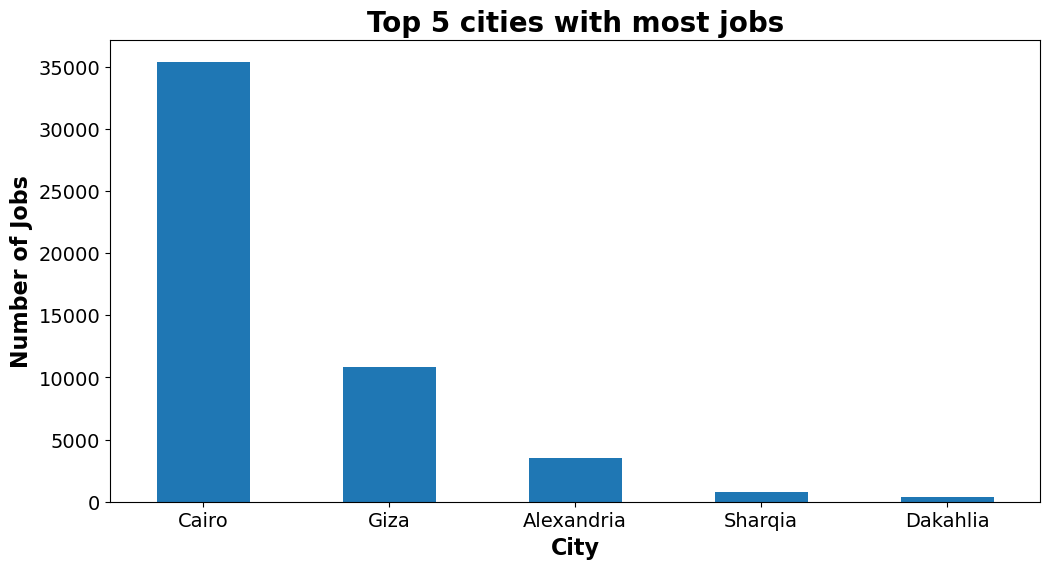

In [247]:
pd.set_option('display.max_rows', None)
aa=df.groupby('city')['job_title'].count().sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,6),fontsize=14,rot=0)
aa.set_xlabel('City',fontsize=16,fontweight='bold')
aa.set_ylabel('Number of Jobs',fontsize=16,fontweight='bold')
aa.set_title('Top 5 cities with most jobs',fontsize=20,fontweight='bold')
plt.show()

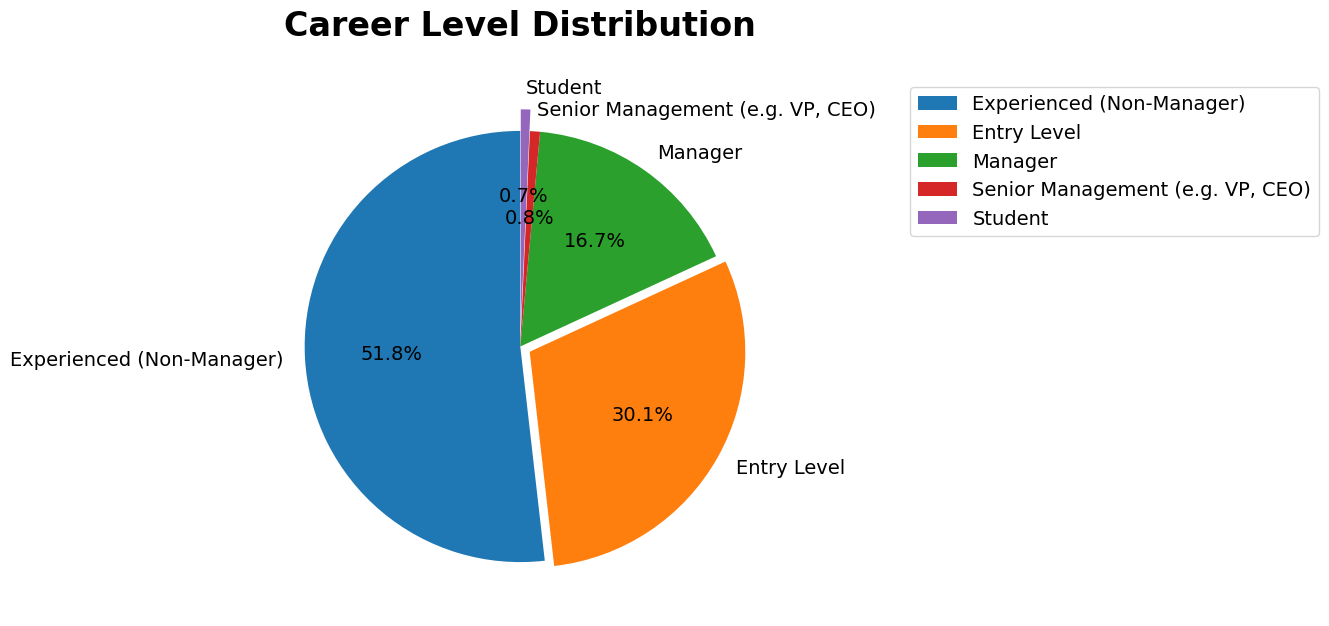

In [396]:
df['career_level'].value_counts().plot(kind='pie',figsize=(7,7),fontsize=14,autopct='%1.1f%%',startangle=90,ylabel='',explode=(0, 0.05, 0, 0, 0.1))
plt.title('Career Level Distribution',fontsize=24,fontweight='bold',pad=30)
plt.legend(loc='upper right',bbox_to_anchor=(2,1),fontsize=14)
plt.show()


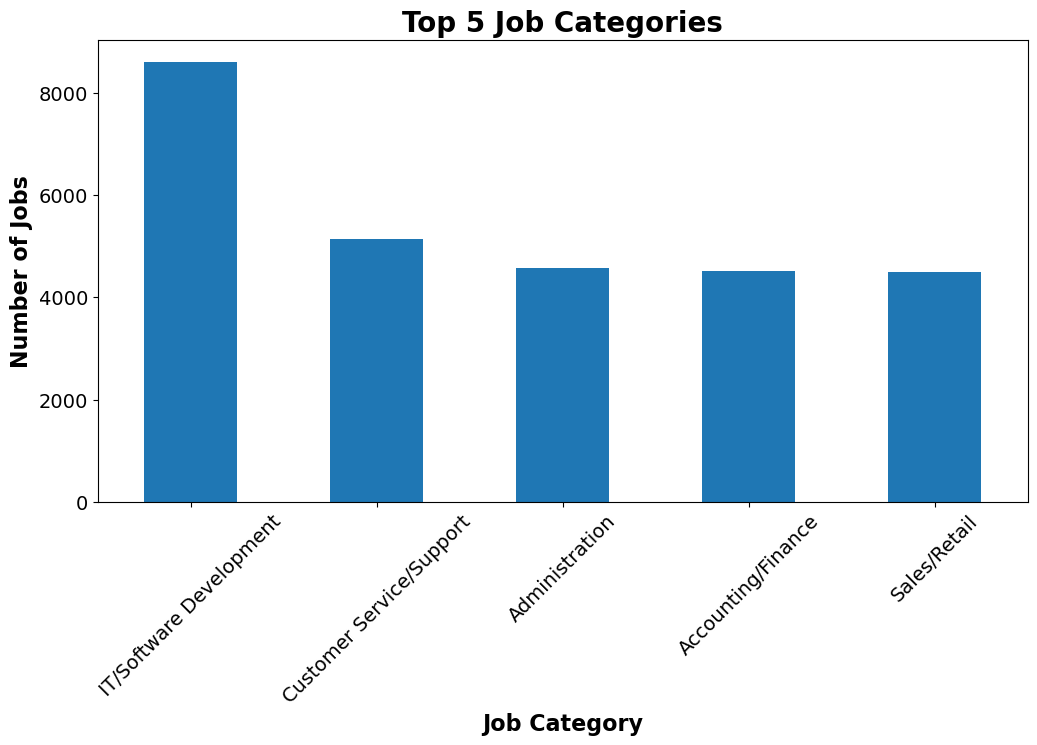

In [ ]:
df['job_category1'].value_counts().sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,6),fontsize=14,rot=45)
plt.title('Top 5 Job Categories',fontsize=20,fontweight='bold')
plt.xlabel('Job Category',fontsize=16,fontweight='bold')
plt.ylabel('Number of Jobs',fontsize=16,fontweight='bold')
plt.show()
# the average salary for each job title

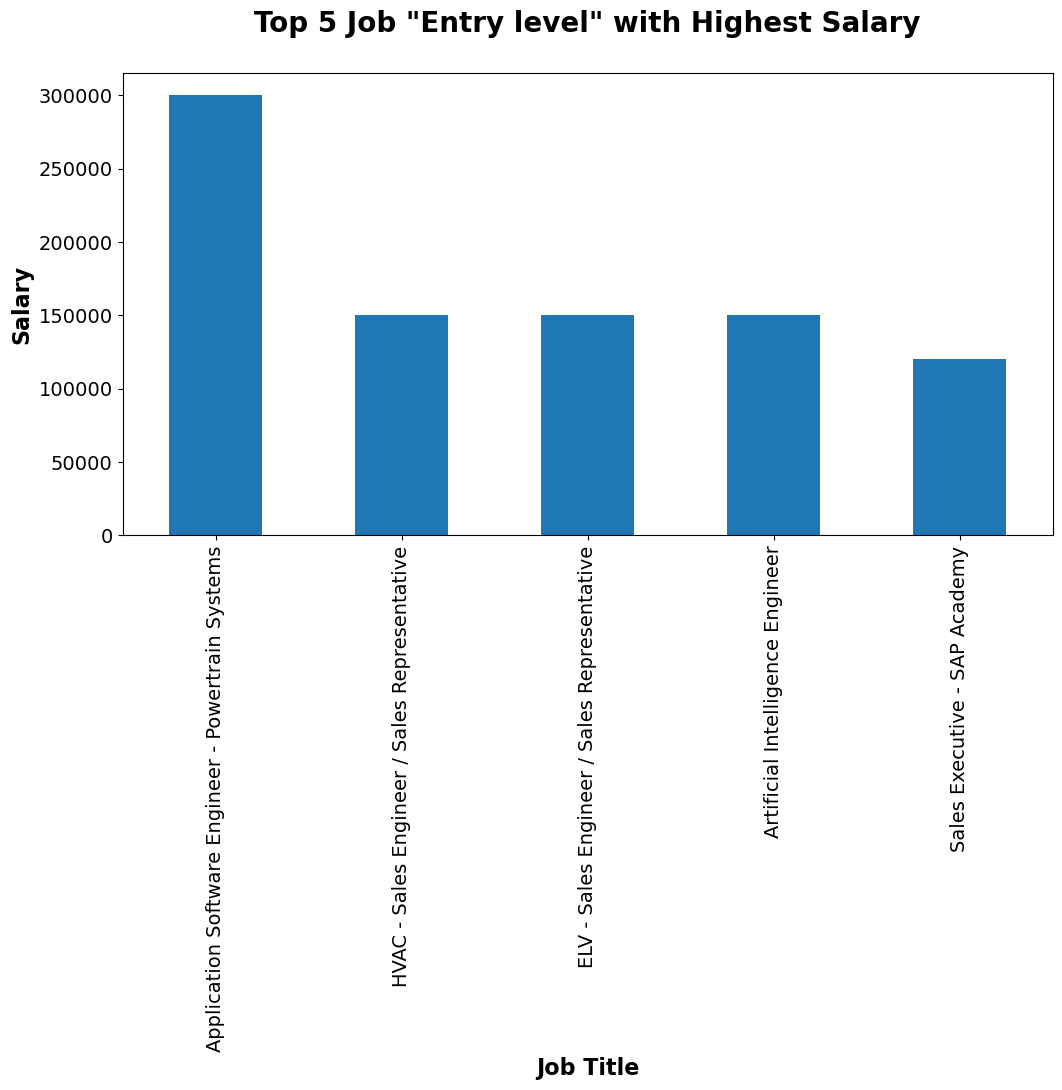

In [422]:
df[(df['currency_name'] == 'Egyptian Pound') & (df['salary_period'] == 'Per Month')&(df['career_level'] == 'Entry Level')]\
    .groupby('job_title')['Max_Salary'] \
    .max() \
    .sort_values(ascending=False) \
    .head(5) \
    .plot(kind='bar', figsize=(12, 6), fontsize=14, rot=90)
plt.title('Top 5 Job "Entry level" with Highest Salary',fontsize=20,fontweight='bold',pad=30)
plt.xlabel('Job Title',fontsize=16,fontweight='bold')
plt.ylabel('Salary',fontsize=16,fontweight='bold')
plt.show()


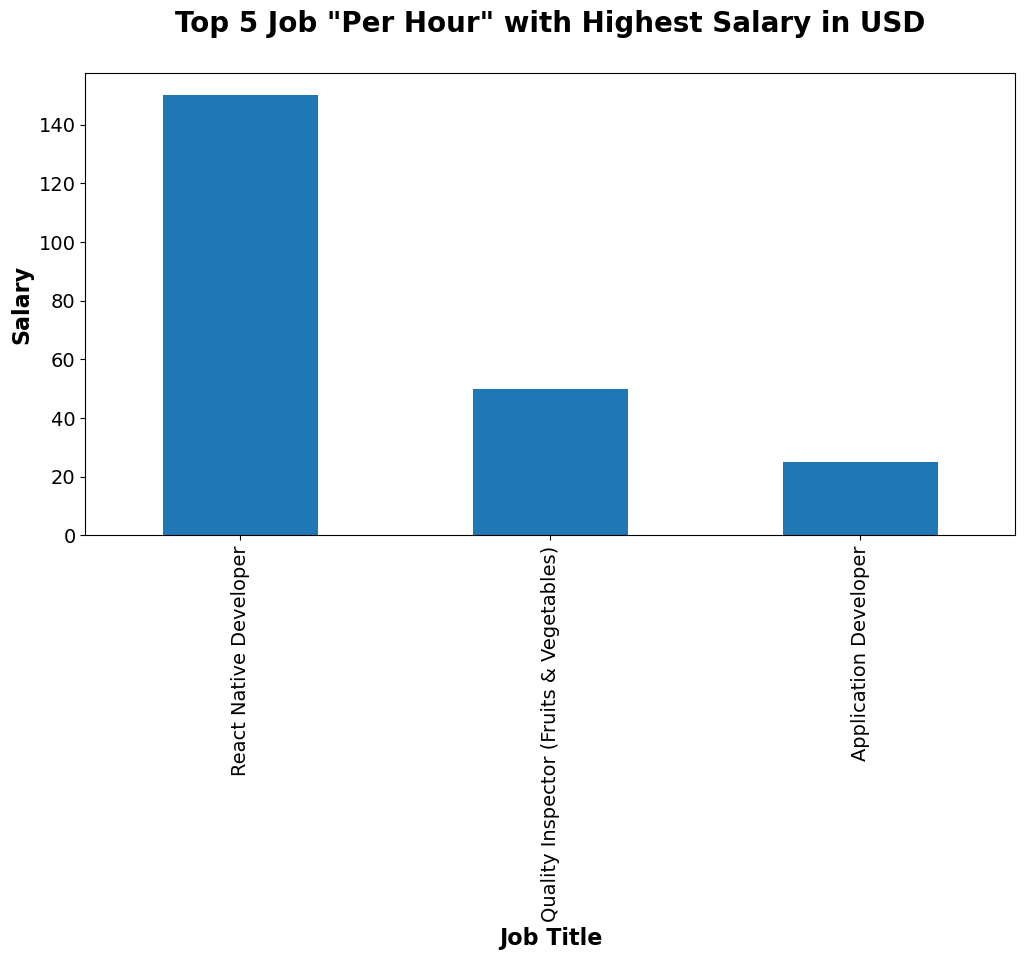

In [438]:
df[(df['currency_name'] == 'United States Dollar') & (df['salary_period'] == 'Per Hour')]\
    .groupby('job_title')['Max_Salary'] \
    .max() \
    .sort_values(ascending=False) \
    .head(3) \
    .plot(kind='bar', figsize=(12, 6), fontsize=14, rot=90)
plt.title('Top 5 Job "Per Hour" with Highest Salary in USD',fontsize=20,fontweight='bold',pad=30)
plt.xlabel('Job Title',fontsize=16,fontweight='bold')
plt.ylabel('Salary',fontsize=16,fontweight='bold')
plt.show()

Text(0.5, 1.0, 'Top 5 Industry with Highest Salary')

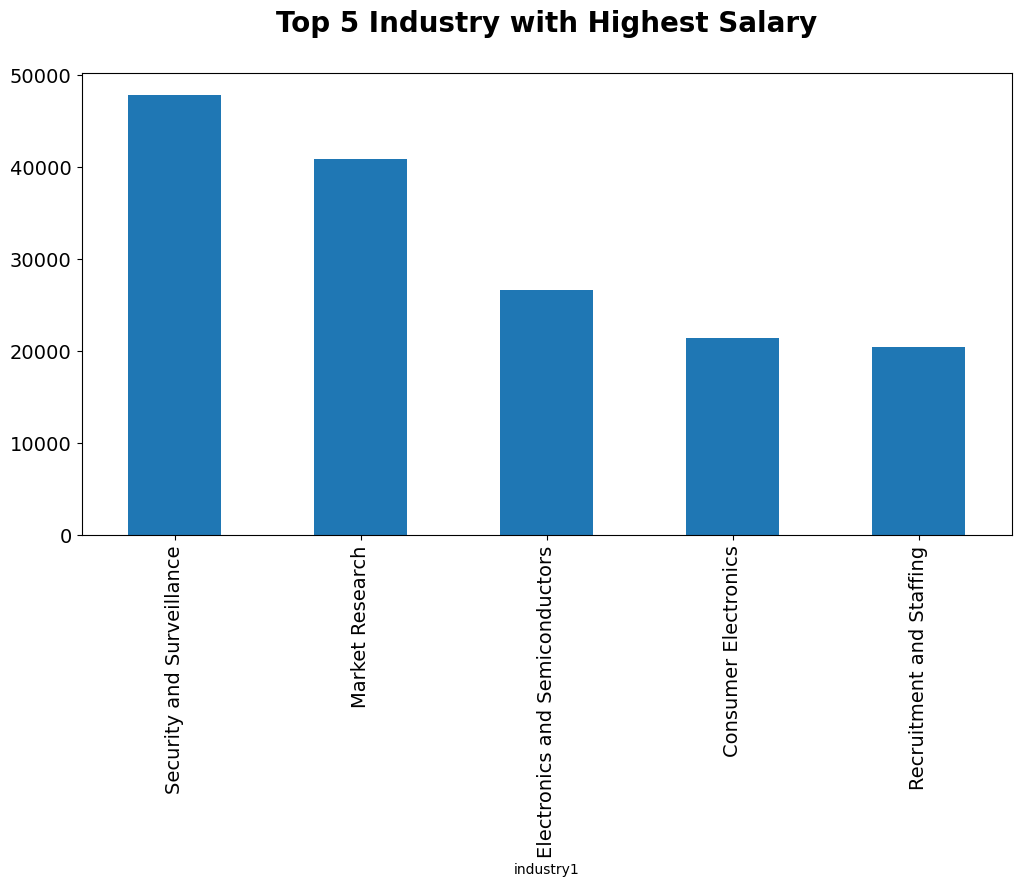

In [441]:
df.groupby('industry1')['Max_Salary'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(5) \
    .plot(kind='bar', figsize=(12, 6), fontsize=14, rot=90)
plt.title('Top 5 Industry with Highest Salary',fontsize=20,fontweight='bold',pad=30)